# Diagnóstico de Calidad de Datos — SECOP II
**Tesis:** Capa de Notarización Digital sobre SECOP II  
**Universidad de los Andes · Ingeniería de Sistemas y Computación**  
**Autor:** Joseph Steven Linares Gutierrez · Bogotá, Colombia · 2026

---

Este notebook documenta el diagnóstico de calidad de datos realizado sobre el conjunto de contratos electrónicos del SECOP II, obtenidos mediante la API Socrata (SODA 2.0). El análisis evalúa cinco dimensiones de calidad, **Completitud, Unicidad, Consistencia, Validez** y accesibilidad de URLs documentales, con el propósito de caracterizar el estado del repositorio de información contractual y establecer las condiciones técnicas bajo las cuales una capa externa de notarización digital resulta viable e implementable.

---
## Sección 0 — Configuración e importación de librerías
---

Se importan las funciones del módulo `calidad_secop2.py`, desarrollado específicamente para este diagnóstico, junto con las librerías estándar de análisis y visualización. Las columnas del dataset se agrupan previamente en listas temáticas, fechas, montos, categorías e identificadores críticos, que actúan como parámetros reutilizables a lo largo de todas las secciones. El detalle de estas agrupaciones se encuentra documentado en el módulo de análisis.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sodapy import Socrata

from calidad_secop2 import (
    # Pre-procesamiento
    preprocesar_todo,
    
    # Completitud
    reporte_completitud, top_entidades_incompletas,
    
    # Unicidad
    reporte_duplicados, analizar_multiples_contratos_por_proceso,
    
    # Consistencia
    verificar_orden_temporal, verificar_montos, verificar_coherencia_modalidad_estado,
    
    # Validez
    verificar_formato_nit, verificar_modalidades_catalogo, verificar_rangos_temporales,
    
    # URLs
    sondear_urls, resumir_sondeo_urls,
    
    # Visualizaciones
    plot_barras_nulos, plot_heatmap_nulos_por_entidad, plot_serie_temporal_contratos,
    plot_distribucion_valores, plot_top_modalidades, plot_urls_status,
    
    # Exportación
    exportar_reporte_calidad, generar_resumen_ejecutivo,
    
    # Constantes
    COLUMNAS_CRITICAS_DEFAULT, COLUMNAS_FECHA_DEFAULT, COLUMNAS_MONTO_DEFAULT,
    COLUMNAS_CATEGORICAS_DEFAULT,
)

A continuación se definen los parámetros de acceso al dataset y las constantes empleadas a lo largo del diagnóstico.

Dado el elevado número de contratos registrados en el dataset y a las restricciones inherentes al uso de Socrata y de la versión SODA 2 para la extracción de datos, el análisis se realizó utilizando una muestra de 1.147.690 filas, equivalente aproximadamente al 20% del total de contratos disponibles al 28/02/2026. Esta proporción resulta adecuada para obtener un diagnóstico representativo del estado general de la información, manteniendo al mismo tiempo la viabilidad computacional del análisis exploratorio.

Las **claves naturales** (`id_contrato`, `proceso_de_compra`) corresponden a los identificadores primarios de cada contrato, razón por la cual se definen de manera implícita en el modelo de datos y se emplean como base para las evaluaciones de unicidad y detección de duplicados.

Por otro lado, los **pares de fechas** definidos corresponden a combinaciones relevantes dentro del ciclo contractual. Estas agrupaciones serán utilizadas en la Sección 5 - Consistencia, donde se evaluará el cumplimiento de los ordenamientos temporales lógicos entre hitos del proceso de contratación.

In [2]:
# Parametros globales
DOMAIN      = 'www.datos.gov.co' # Pagina de Socrata para SECOP II
DATASET_ID  = 'jbjy-vk9h' # Identificador del dataset de contratos electronicos
APP_TOKEN   = os.getenv('SOCRATA_APP_TOKEN', None)

LIMIT_MUESTRA   = 1147690 #20%
N_URLS_SONDEO   = 100
RUTA_SALIDA     = './artefactos_calidad'  # Carpeta de salida
SEMILLA         = 42 # Valor random para reproducibilidad

# Claves naturales del SECOP II
CLAVES_NATURALES = ['id_contrato', 'proceso_de_compra']

# Pares de fechas a verificar
PARES_FECHA = [
    ('fecha_de_firma', 'fecha_de_inicio_del_contrato'),
    ('fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato'),
    ('fecha_de_firma', 'fecha_de_fin_del_contrato'),
]

os.makedirs(RUTA_SALIDA, exist_ok=True)

---
## SECCIÓN 1 — Carga de Datos (Socrata SODA 2.0)
---

Los datos se obtienen directamente desde el portal de datos abiertos [www.datos.gov.co](https://www.datos.gov.co) mediante el cliente `sodapy`, que implementa la API Socrata Open Data (SODA 2.0). Dado que la API impone un límite de **50.000 registros por petición**, la extracción se realiza mediante paginación secuencial hasta alcanzar el tamaño de muestra definido.

In [3]:
# 1.1 Cargar datos desde Socrata
client  = Socrata(DOMAIN, APP_TOKEN, timeout=120)
limit   = 50000
offset  = 0
all_rows = []

print(f'Cargando hasta {LIMIT_MUESTRA:,} registros...')

while len(all_rows) < LIMIT_MUESTRA:
    batch = client.get(DATASET_ID, limit=limit, offset=offset)
    
    if not batch:
        break
    
    all_rows.extend(batch)
    print(f'  Registros acumulados: {len(all_rows):,}') #indicador de progreso
    offset += limit
    
    if len(batch) < limit:   # última página
        break

data_raw = pd.DataFrame.from_records(all_rows[:LIMIT_MUESTRA])

print(f'\n Datos cargados (filas x columnas): {data_raw.shape}')

Cargando hasta 1,147,690 registros...
  Registros acumulados: 50,000
  Registros acumulados: 100,000
  Registros acumulados: 150,000
  Registros acumulados: 200,000
  Registros acumulados: 250,000
  Registros acumulados: 300,000
  Registros acumulados: 350,000
  Registros acumulados: 400,000
  Registros acumulados: 450,000
  Registros acumulados: 500,000
  Registros acumulados: 550,000
  Registros acumulados: 600,000
  Registros acumulados: 650,000
  Registros acumulados: 700,000
  Registros acumulados: 750,000
  Registros acumulados: 800,000
  Registros acumulados: 850,000
  Registros acumulados: 900,000
  Registros acumulados: 950,000
  Registros acumulados: 1,000,000
  Registros acumulados: 1,050,000
  Registros acumulados: 1,100,000
  Registros acumulados: 1,150,000

 Datos cargados (filas x columnas): (1147690, 87)


In [4]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147690 entries, 0 to 1147689
Data columns (total 87 columns):
 #   Column                                                            Non-Null Count    Dtype 
---  ------                                                            --------------    ----- 
 0   nombre_entidad                                                    1147690 non-null  object
 1   nit_entidad                                                       1147690 non-null  object
 2   departamento                                                      1147690 non-null  object
 3   ciudad                                                            1147690 non-null  object
 4   localizaci_n                                                      1147690 non-null  object
 5   orden                                                             1147690 non-null  object
 6   sector                                                            1147690 non-null  object
 7   rama              

In [5]:
# 1.2 Inspección de los datos cargados
print('\nPrimeras filas:')
display(data_raw.head(5))


Primeras filas:


,nombre_entidad,nit_entidad,departamento,ciudad,localizaci_n,orden,sector,rama,entidad_centralizada,proceso_de_compra,...,nombre_ordenador_de_pago,tipo_de_documento_ordenador_de_pago,n_mero_de_documento_ordenador_de_pago,documentos_tipo,descripcion_documentos_tipo,fecha_de_firma,ultima_actualizacion,fecha_de_notificaci_n_de_prorrogaci_n,fecha_inicio_liquidacion,fecha_fin_liquidacion
0,JEP,901140004,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,No aplica/No pertenece,Corporación Autónoma,Centralizada,CO1.BDOS.1108279,...,No definido,No definido,No definido,No,No definido,NaN,NaN,NaN,NaN,NaN
1,ALCALDIA MUNICIPIO DE ARAUCA,800102504,Arauca,Arauca,"Colombia, Arauca , Arauca",Territorial,Servicio Público,Ejecutivo,Descentralizada,CO1.BDOS.3106524,...,No definido,No definido,No definido,No,No definido,2022-08-04T00:00:00.000,2023-07-05T00:00:00.000,NaN,NaN,NaN
2,SECRETARIA GENERAL Y DE CERCANIA AL CIUDADANO,899999114,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Territorial,No aplica/No pertenece,Ejecutivo,Centralizada,CO1.BDOS.9463073,...,No definido,No definido,No definido,No,No definido,2026-01-13T00:00:00.000,NaN,NaN,NaN,NaN
3,ALCALDIA MUNICIPAL DE VALLEDUPAR,800098911,Cesar,Valledupar,"Colombia, Cesar , Valledupar",Territorial,Servicio Público,Ejecutivo,Centralizada,CO1.BDOS.2250151,...,No definido,No definido,No definido,No,No definido,2021-09-16T00:00:00.000,2021-10-19T00:00:00.000,NaN,NaN,NaN
4,MINISTERIO DE MINAS Y ENERGIA,899999022,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,Minas y Energía,Ejecutivo,Centralizada,CO1.BDOS.4621217,...,No definido,No definido,No definido,No,No definido,2023-06-28T00:00:00.000,NaN,NaN,NaN,NaN


A partir de los datos inicialmente cargados en el dataframe, es posible observar que **todas las columnas son recibidas como tipo `object`** desde la API, independientemente de su naturaleza real. De igual forma se observa que una parte significativa de los registros presenta valores vacíos, etiquetas como “No definido”, valores NaN, así como inconsistencias en los tipos de datos, incluyendo la coexistencia de enteros, cadenas de texto y fechas en columnas que deberían ser homogéneas. También se identifican estructuras con variaciones en campos que contienen enlaces como en el campo `urlproceso`.

Estas primeras observaciones permiten establecer un diagnóstico preliminar del estado del dataset y justifican la necesidad de realizar un paso de pre-procesamiento previo a avanzar hacia la evaluación formal de las dimensiones de calidad de datos.

---
## SECCIÓN 2 — Pre-procesamiento
---

Antes de evaluar las dimensiones de calidad, se aplica un conjunto de transformaciones mínimas y reproducibles que homogenizan el dataset: extracción y limpieza del campo de URLs, estandarización de valores ausentes bajo una representación única (`NaN`), tipificación de columnas temporales a `datetime64[ns]`, conversión de columnas monetarias a `int64`, y normalización de variables categóricas mediante eliminación de espacios y unificación de capitalización. Estas transformaciones están implementadas en el módulo `calidad_secop2.py` y se invocan a través de la función `preprocesar_todo()`.


In [6]:
# 2.1 Pipeline de pre-procesamiento
data = preprocesar_todo(
    data_raw,
    'urlproceso',
    COLUMNAS_FECHA_DEFAULT,
    COLUMNAS_MONTO_DEFAULT,
    COLUMNAS_CATEGORICAS_DEFAULT,
)

PIPELINE DE PRE-PROCESAMIENTO
[extraer_url] URLs extraídas: 1,147,690 | Vacías/inválidas: 0 (0.0%)
[estandarizar_vacios] Tokens vacíos convertidos a NaN: 14,186,121
[normalizar_fechas] Resumen de conversión:
                              columna  nulos_previos  NaT_nuevos_por_conversion
                       fecha_de_firma              0                      82730
         fecha_de_inicio_del_contrato              0                      91706
            fecha_de_fin_del_contrato              0                      10972
                 ultima_actualizacion              0                     535992
fecha_de_notificaci_n_de_prorrogaci_n              0                    1034824
             fecha_inicio_liquidacion              0                    1018876
                fecha_fin_liquidacion              0                    1018881

[normalizar_numericos] Resumen de conversión:
                     columna dtype_final  NaN_nuevos
          valor_del_contrato       int64           0

In [7]:
print('Muestra aleatoria:')
display(data.sample(3, random_state=SEMILLA))

Muestra aleatoria:


,nombre_entidad,nit_entidad,departamento,ciudad,localizaci_n,orden,sector,rama,entidad_centralizada,proceso_de_compra,...,tipo_de_documento_ordenador_de_pago,n_mero_de_documento_ordenador_de_pago,documentos_tipo,descripcion_documentos_tipo,fecha_de_firma,ultima_actualizacion,fecha_de_notificaci_n_de_prorrogaci_n,fecha_inicio_liquidacion,fecha_fin_liquidacion,urlproceso_clean
299007,MUNICIPIO DE PAMPLONA,800007652,Norte de Santander,Pamplona,"Colombia, Norte de Santander , Pamplona",NACIONAL,SERVICIO PÚBLICO,EJECUTIVO,DESCENTRALIZADA,CO1.BDOS.9653558,...,NaN,NaN,No,NaN,2026-01-22,NaT,NaT,NaT,NaT,https://community.secop.gov.co/Public/Tenderin...
1100800,DANE CENTRO OCCIDENTE,899999027,Caldas,Manizales,"Colombia, Caldas, Manizales",NACIONAL,SERVICIO PÚBLICO,EJECUTIVO,CENTRALIZADA,CO1.BDOS.6480269,...,NaN,NaN,No,NaN,2024-08-05,2025-12-12,NaT,NaT,NaT,https://community.secop.gov.co/Public/Tenderin...
474350,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,890399011,Valle del Cauca,Cali,"Colombia, Valle del Cauca , Cali",TERRITORIAL,"VIVIENDA, CIUDAD Y TERRITORIO",EJECUTIVO,CENTRALIZADA,CO1.BDOS.1933942,...,NaN,NaN,No,NaN,NaT,NaT,NaT,NaT,NaT,https://community.secop.gov.co/Public/Tenderin...


La ejecución de la función *preprocesar_todo()* permite unificar y estandarizar el tratamiento de los datos provenientes del SECOP II. En primer lugar, la función normaliza la estructura del campo de URLs, integrando el formato diccionario que en él se tiene en una única columna denominada `urlproceso_clean`, lo que facilita tanto su análisis como su posterior verificación.

Adicionalmente, para garantizar una adecuada medición de la completitud, se definió el arreglo TOKENS_VACIO, compuesto por distintos símbolos y palabras comúnmente utilizados para representar valores ausentes en los datos abiertos. Estos tokens se transforman explícitamente en NaN, permitiendo una contabilización correcta de los vacíos y evitando interpretaciones ambiguas durante el análisis.

Finalmente, fue necesario construir manualmente listas de columnas que contienen fechas (COLUMNAS_FECHA_DEFAULT), valores numéricos (COLUMNAS_MONTO_DEFAULT) o categorías textuales (COLUMNAS_CATEGORICAS_DEFAULT), con el fin de asegurar una conversión homogénea de sus tipos: fechas a datetime64[ns] o NaT, montos a int64, y categóricas a tipos de texto limpios y normalizados.

El dataset resultante conserva las **1147690 filas × 87 columnas** originales con los tipos de dato apropiados para el análisis de calidad.

---
## SECCIÓN 3 — Completitud
---

Esta dimensión busca medir la proporción de valores ausentes en los campos críticos del dataset por lo que se definen dos umbrales de alerta: **5%** (Advertencia) y **20%** (Crítico), diferenciados según la naturaleza del campo. Para el caso de los identificadores de contrato se tiene un umbral más estricto del 1%, dado que su ausencia impide la trazabilidad del registro en la capa de notarización.


In [8]:
# 3.1 Reporte de completitud por campo crítico
df_completitud = reporte_completitud(
    data,
    columnas_criticas=COLUMNAS_CRITICAS_DEFAULT,
    ids_estrictos=['id_contrato', 'proceso_de_compra', 'nit_entidad'],
)
display(df_completitud)


[reporte_completitud] Resumen de severidad:
  CRÍTICO     : 1 campo(s)
  ADVERTENCIA : 2 campo(s)
  OK          : 13 campo(s)


,campo,n_total,n_nulos,pct_nulo,severidad
15,ciudad,1147690,250565,21.83,CRÍTICO
11,fecha_de_inicio_del_contrato,1147690,91706,7.99,ADVERTENCIA
10,fecha_de_firma,1147690,82730,7.21,ADVERTENCIA
4,documento_proveedor,1147690,34980,3.05,OK
14,departamento,1147690,23750,2.07,OK
12,fecha_de_fin_del_contrato,1147690,10972,0.96,OK
5,proveedor_adjudicado,1147690,206,0.02,OK
0,id_contrato,1147690,0,0.00,OK
7,modalidad_de_contratacion,1147690,0,0.00,OK
6,valor_del_contrato,1147690,0,0.00,OK


[plot_barras_nulos] Figura guardada en: ./artefactos_calidad\fig_completitud_nulos.png


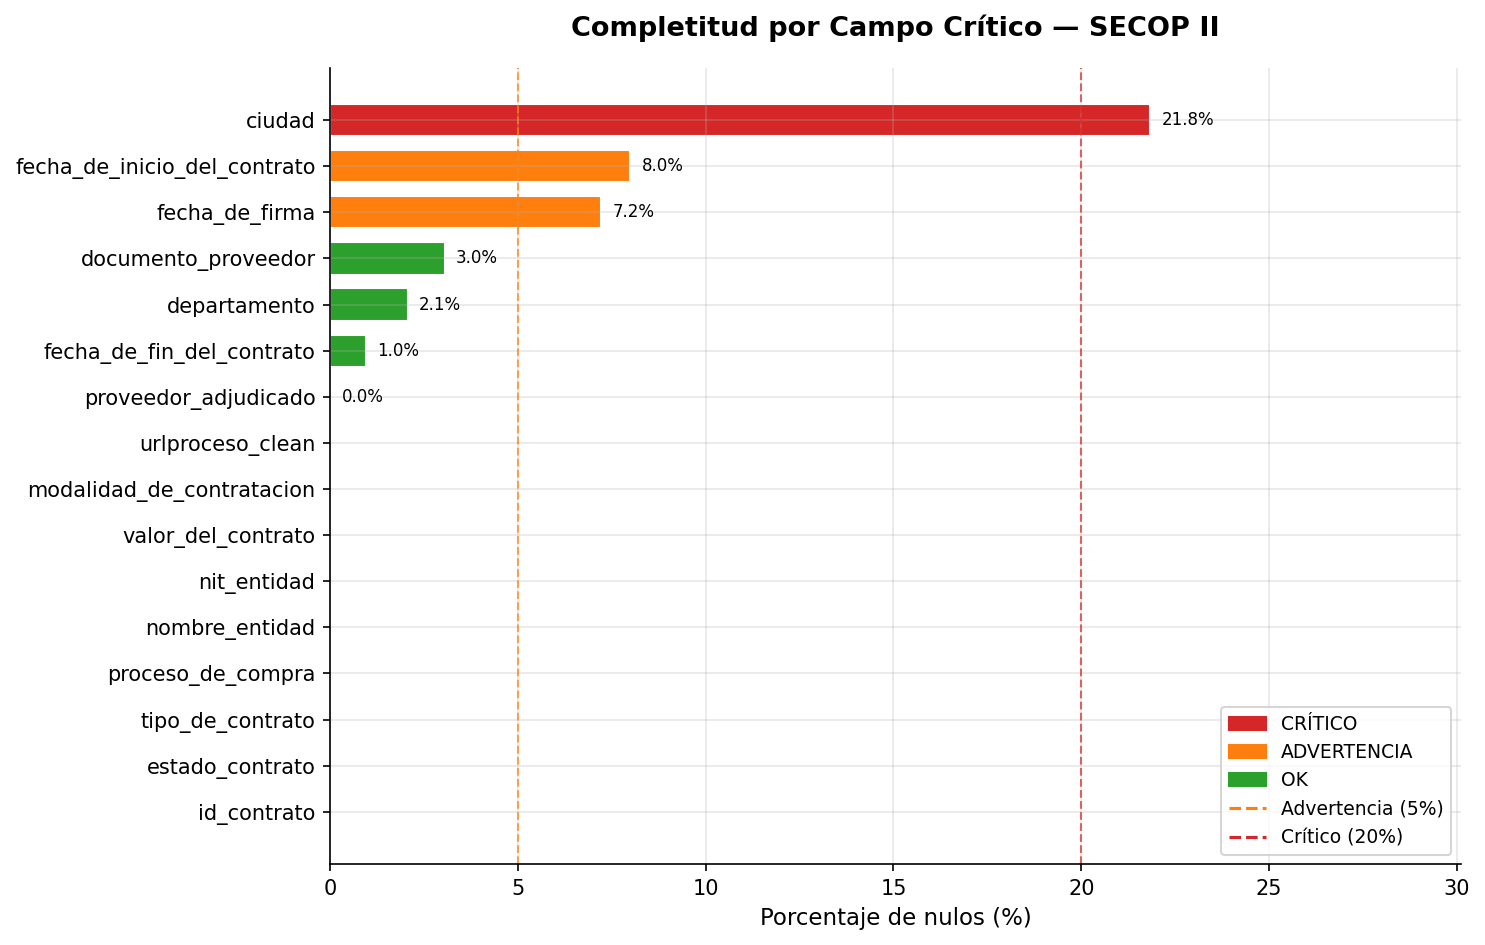

In [9]:
# 3.2 Gráfico: barras horizontales de nulos
plot_barras_nulos(
    df_completitud,
    titulo='Completitud por Campo Crítico — SECOP II',
    guardar_en=os.path.join(RUTA_SALIDA, 'fig_completitud_nulos.png'),
)

El gráfico muestra el porcentaje de valores nulos en campos considerados críticos. Con base en la muestra analizada, se observa que el único elemento con un valor **Crítico** es el de `ciudad` con **21,8%** de nulos. Indicando que una de cada cinco filas no posee una ciudad vinculada. Para el caso de **Advertencia** los unicos elementos entre este rango fueron `fecha_de_inicio_del_contrato` con **8%** de nulos y `fecha_de_firma` con **7,2%** de nulos. El resto de elementos al estar por debajo del umbral de advertencia se consideran no relevantes para analisis posteriores.

La razón para el percentil elevado en el caso de los elementos de (`ciudad`) se atribuye a que los contratos suelen ser menos estables en publicaciones administrativas ya que algunos procesos se registran con foco en la entidad contratante o el ámbito departamental por lo que no siempre se diligencia el departamento o ciudad, especialmente en contratos con cobertura nacional.  

Para el caso de las fechas operativas (`fecha_de_firma`, `fecha_de_inicio_del_contrato`) estas pueden presentar ausencias por desfase en carga, actualizaciones tardías o no aplicabilidad temporal. En ese sentido, el patrón observado no es inusual en datos transaccionales gubernamentales. Sin embargo, estos requieren de un tratamiento adecuado porque afecta series de tiempo, reglas de consistencia y análisis territoriales.

In [10]:
# 3.3 Top entidades con mayor incompletitud
df_top_entidades = top_entidades_incompletas(
    data,
    columnas_criticas=COLUMNAS_CRITICAS_DEFAULT,
    top_n=20,
)
display(df_top_entidades)

[top_entidades_incompletas] Top 20 entidades con mayor incompletitud:


,nombre_entidad,n_contratos,pct_incompleto_promedio
0,FONDO DE GARANTÍAS DE ENTIDADES COOPERATIVAS -...,1,40.00
1,INSTITUCION EDUCATIVA RURAL SANPEREGRINO MANIZ...,1,40.00
2,ELECTRIFICADORA DEL META S.A E.S.P,1,40.00
3,INSTITUCION EDUCATIVA JOSE ACEVEDO Y GOMEZ,1,40.00
4,INSTITUCION EDUCATIVA TECNICA ENRIQUE OLAYA HE...,1,40.00
5,COLEGIO SOTAVENTO IED,1,40.00
6,INSTITUCION EDUCATIVA MUNICIPAL JOSE CELESTINO...,1,40.00
7,INSTITUCION EDUCATIVA JOSE MARIA CORDOBA,1,40.00
8,INSTITUCION EDUCATIVA JULIO FERNANDEZ MEDINA,1,40.00
9,COLEGIO ECOLOGICO DE FLORIDABLANCA,1,40.00


[plot_heatmap_nulos_por_entidad] Figura guardada en: ./artefactos_calidad\fig_heatmap_entidades.png


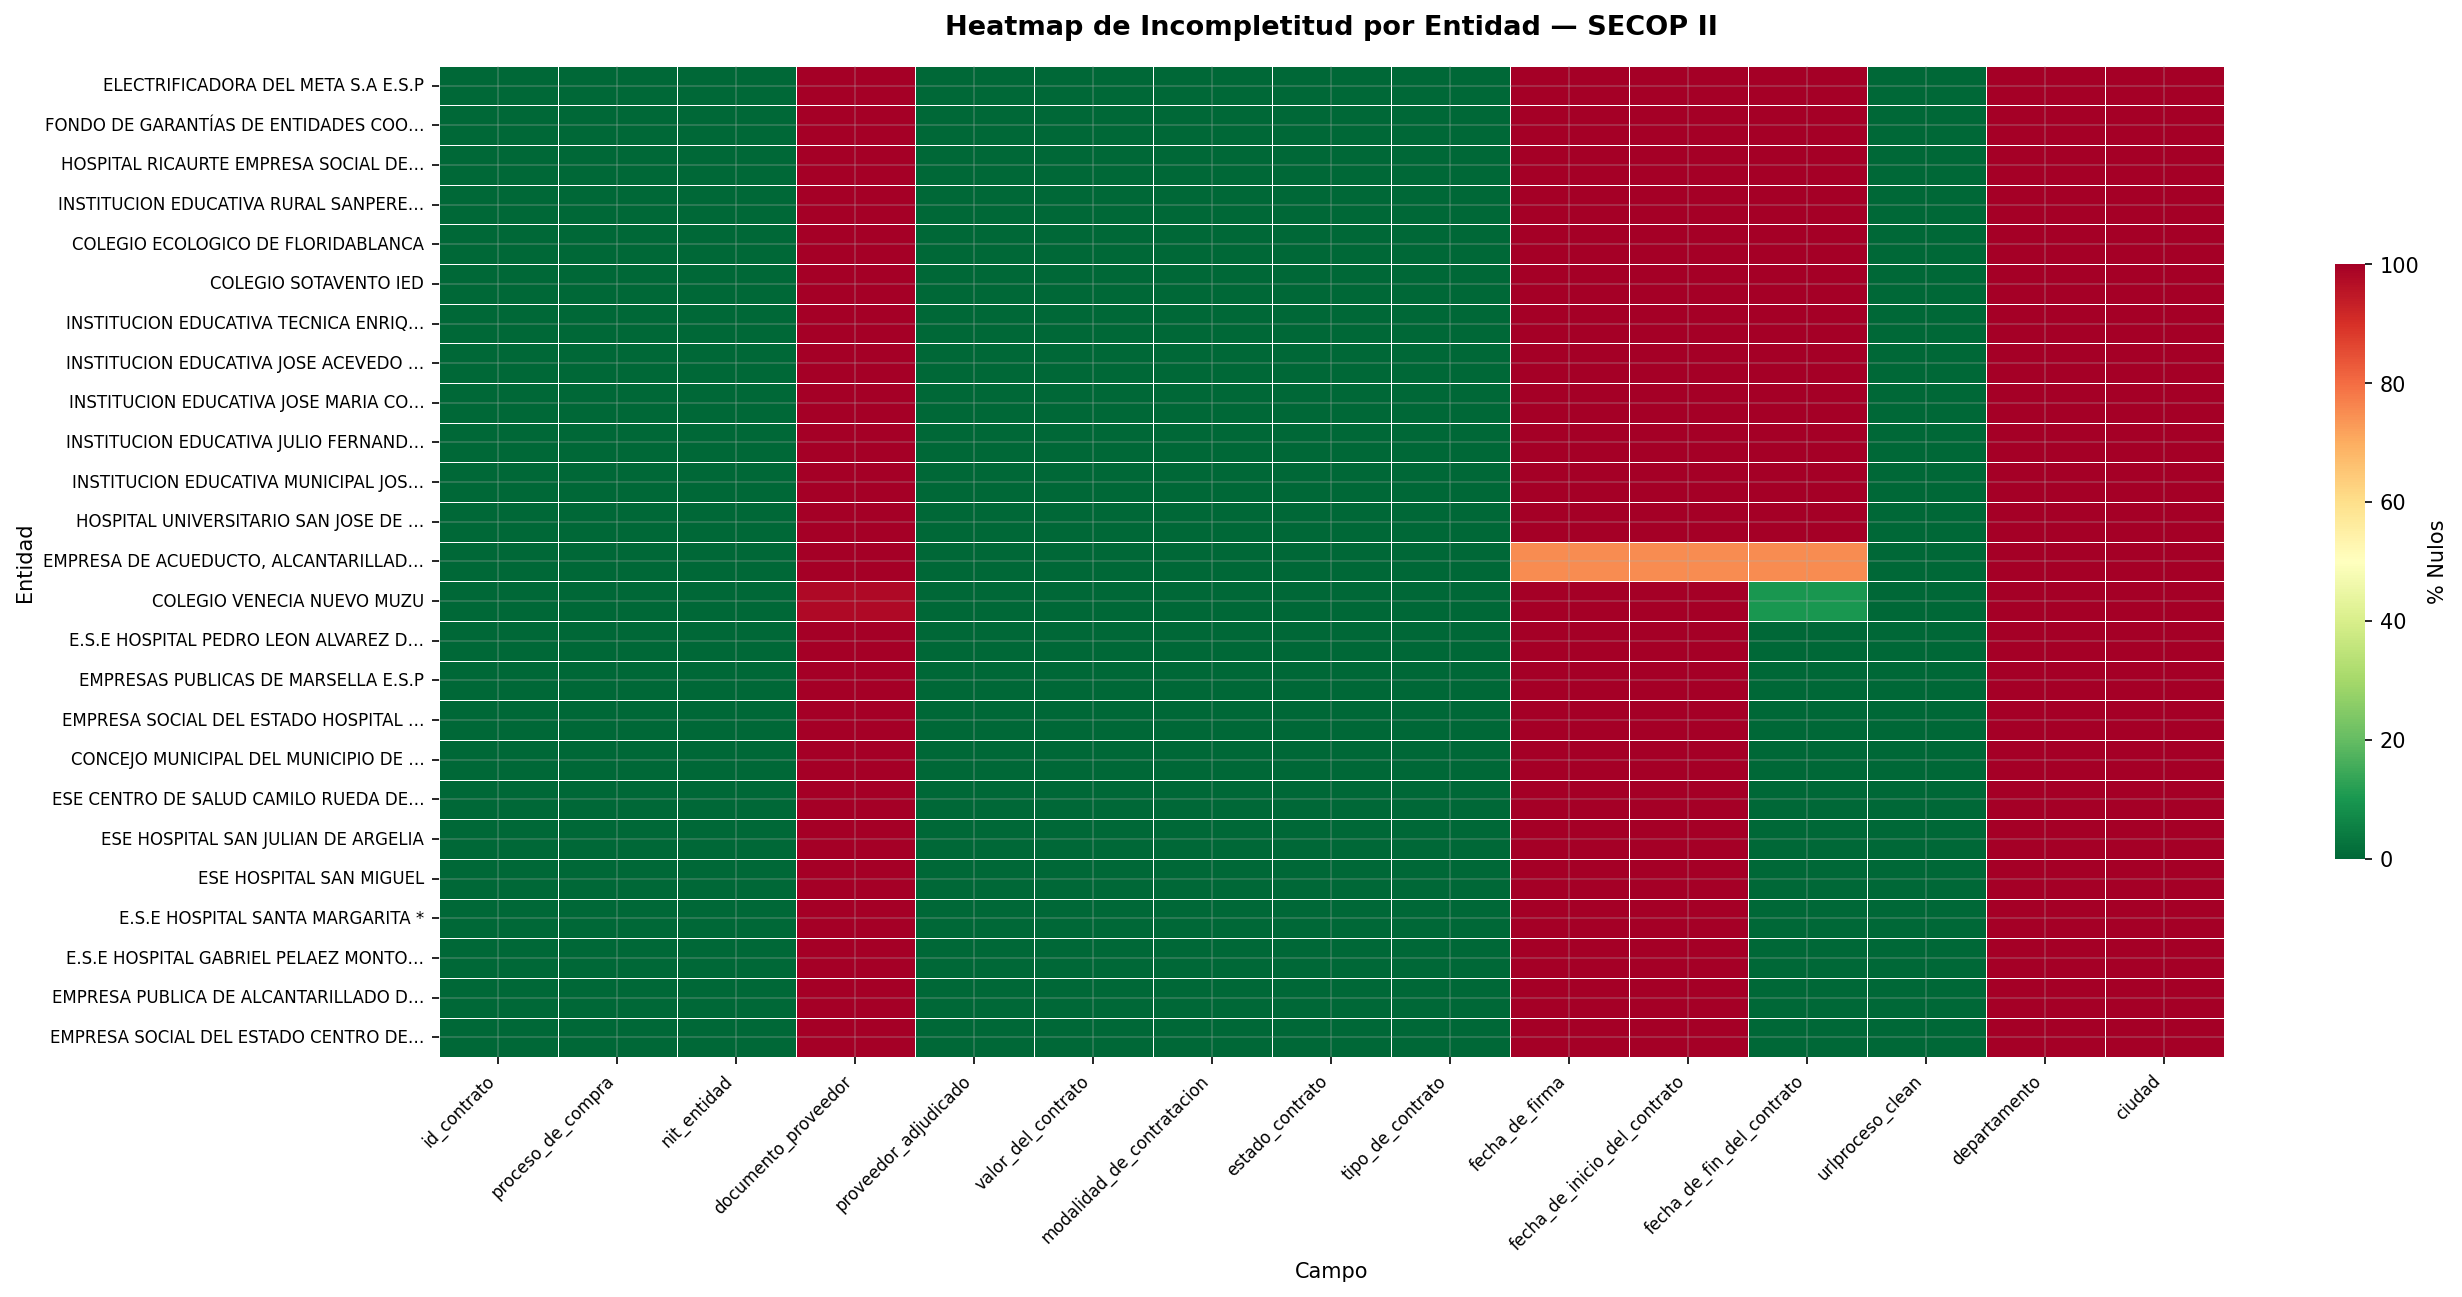

In [11]:
# 3.4 Heatmap entidades vs campos
plot_heatmap_nulos_por_entidad(
    data,
    columnas_criticas=COLUMNAS_CRITICAS_DEFAULT,
    top_n=25,
    titulo='Heatmap de Incompletitud por Entidad — SECOP II',
    guardar_en=os.path.join(RUTA_SALIDA, 'fig_heatmap_entidades.png'),
)


El mapa de calor presenta el % de nulos por campo y por entidad donde la escala va de verde **(0% nulos)** a rojo **(100% nulos)**. Esto con el proposito de ilustrar visualmente que porcentaje predomina en la mayoría de campos y entidades, asi como donde se concentran las bandas **naranja/rojo**, relevantes para la compresión de completitud de datos.

A termino general se establece que hay una alta completitud en variables claves (`id_contrato`, `proceso_de_compra`) y variables núcleo (`valor_del_contrato`, `estado_contrato`, `modalidad_de_contratación`, `nit_entidad`, `nombre_entidad`). Sin embargo, resultan de particular interes los campos variables territoriales asi como las fechas operativas al contener datos incompletos a nivel de municipio como ausencias por desfase de cargue o procesos cancelados/modificados respectivamente.  

A pesar de la ausencia de estos datos el patrón observado es, por tanto, **esperable**, pero debe gestionarse correctamente en caso de realizar análisis temporales y geoespaciales, así como antes de incorporar un registro al pipeline de notarización.

---
## SECCIÓN 4 — Unicidad
---

A continuación se evalúa la existencia de registros duplicados que puedan introducir sesgos en los cómputos agregados o generar colisiones en el proceso de hashing. Se distinguen dos tipos de duplicado: los **exactos** (filas idénticas en todos sus campos) y los **duplicados por clave natural** (mismo `id_contrato` o `proceso_de_compra` con diferencias en otros campos), que pueden corresponder a versiones legítimas del ciclo contractual o a errores de carga.


In [12]:
# 4.1 Duplicados exactos y por clave natural 
resultado_duplicados = reporte_duplicados(data, claves_naturales=CLAVES_NATURALES)

# Ver los duplicados por clave para inspección
if len(resultado_duplicados['df_duplicados_clave']) > 0:
    print('\nMuestra de registros duplicados por clave:')
    display(resultado_duplicados['df_duplicados_clave'][
        CLAVES_NATURALES + ['nombre_entidad', 'valor_del_contrato', 'fecha_de_firma']
    ].head(10))


[reporte_duplicados]
  Duplicados exactos      : 748 (0.065%) OK
  Duplicados por clave    : 17,510 (1.526%) ALERTA
  Claves usadas           : ['id_contrato', 'proceso_de_compra']

Muestra de registros duplicados por clave:


,id_contrato,proceso_de_compra,nombre_entidad,valor_del_contrato,fecha_de_firma
639696,CO1.PCCNTR.1001,CO1.BDOS.5901,COLOMBIA COMPRA EFICIENTE,14420000,NaT
1014421,CO1.PCCNTR.1001,CO1.BDOS.5901,COLOMBIA COMPRA EFICIENTE,14420000,NaT
283723,CO1.PCCNTR.1002926,CO1.BDOS.847936,ARMADA NACIONAL BASE NAVAL No. 6 ARC BOGOTA,19039904,2019-06-25
355881,CO1.PCCNTR.1002926,CO1.BDOS.847936,ARMADA NACIONAL BASE NAVAL No. 6 ARC BOGOTA,19039904,2019-06-25
1054263,CO1.PCCNTR.1004709,CO1.BDOS.861659,INSTITUTO NACIONAL PENITENCIARIO Y CARCELARIO ...,1499050,2019-06-26
1084273,CO1.PCCNTR.1004709,CO1.BDOS.861659,INSTITUTO NACIONAL PENITENCIARIO Y CARCELARIO ...,1499050,2019-06-26
603731,CO1.PCCNTR.1005028,CO1.BDOS.859201,UNIDAD DE GESTION PENSIONAL Y PARAFISCALES - UGPP,1071000,2019-06-21
950571,CO1.PCCNTR.1005028,CO1.BDOS.859201,UNIDAD DE GESTION PENSIONAL Y PARAFISCALES - UGPP,1071000,2019-06-21
559973,CO1.PCCNTR.1005032,CO1.BDOS.859912,EPMSC RIOHACHA,3486000,2019-07-05
706181,CO1.PCCNTR.1005032,CO1.BDOS.859912,EPMSC RIOHACHA,3486000,2019-07-05


Se detectó un **0,065%** de duplicados exactos, correspondientes a cargas repetidas de registros idénticos, y un **1,526%** de duplicados por clave natural (`id_contrato`, `proceso_de_compra`). Este último patrón es característico de los datos abiertos del SECOP II, donde las actualizaciones del ciclo contractual como firma, modificaciones, adiciones y liquidación se publican frecuentemente como nuevas filas en lugar de actualizarse sobre el registro existente (*upsert*), generando versiones múltiples de un mismo contrato.

Para los análisis subsiguientes, los duplicados exactos son candidatos directos a eliminación. Los duplicados por clave natural requieren una estrategia de consolidación basada en el campo `estado_contrato` y en las fechas más recientes disponibles, a fin de retener la versión más actualizada de cada proceso.

Esta condición tiene una implicación arquitectónica relevante en la capa de notarización pues esta deberá incorporar un mecanismo de **versionamiento explícito** (hash + timestamp) que permita registrar cada versión del contrato de forma trazable, sin considerar duplicados como registros independientes.

In [13]:
# 4.2 Análisis de procesos con múltiples contratos
df_multiples = analizar_multiples_contratos_por_proceso(data, umbral_sospechoso=5)


[analizar_multiples_contratos]
  Procesos únicos            : 1,053,686
  Procesos sospechosos (>5): 4,266 (0.40%)
  Proceso con más contratos  : CO1.BDOS.1090482 (130 contratos)


Los resultados muestran que en la muestra analizada existen **1.053.686 procesos únicos**, lo cual confirma que la clave `proceso_de_compra` funciona correctamente como identificador de alto nivel del ciclo contractual. Sin embargo, se identifican **4.266 procesos (0,40%)** con más de 5 contratos asociados, clasificados como procesos sospechosos. Algunas exlicaciones a esto dentro del funcionamiento real del SECOP II son:

1. **Versionamiento del ciclo contractual:**
    En SECOP II los contratos pueden generar múltiples registros asociados al mismo proceso cuando se realizan actividades como: modificaciones contractuales, prórrogas, adiciones, subsanaciones, republicaciones o ajustes administrativos. El portal permite llevar seguimiento del ciclo de vida completo, lo que puede reflejarse como múltiples “contratos electrónicos” vinculados al mismo proceso.

2. **Publicaciones acumulativas:**
    Si las entidades cargan información mediante mecanismos que no actualizan el registro previo (como reemplazo o upsert), sino que agregan una nueva fila, esto produce múltiples contratos para un mismo proceso, aun cuando se trate de correcciones o re‑publicaciones.

3. **Errores de registro:**
    Un pequeño porcentaje puede corresponder a errores de registro, procesos mal configurados o cargas masivas repetidas por parte de algunas entidades.

In [14]:
display(df_multiples.head(15))

,proceso_de_compra,n_contratos,n_ids_unicos,n_estados_distintos,valor_total,sospechoso
11649,CO1.BDOS.1090482,130,130,5,2377786570,True
410281,CO1.BDOS.4130106,108,107,3,6949533721,True
575430,CO1.BDOS.5749845,100,100,5,876035579,True
254993,CO1.BDOS.2794304,93,93,6,4312430308,True
535115,CO1.BDOS.5430521,91,91,5,1947583818,True
1041536,CO1.BDOS.9859470,87,87,5,1016090100,True
1034554,CO1.BDOS.9816209,82,82,3,799204800,True
419408,CO1.BDOS.4214324,82,82,5,3785813140,True
543225,CO1.BDOS.5495114,80,80,6,1722287079,True
12224,CO1.BDOS.1093835,76,76,2,2810473467,True


El caso extremo identificado corresponde al proceso **CO1.BDOS.1090482**, con **130 contratos asociados**. Este volumen puede responder a un ciclo contractual de larga duración con múltiples modificaciones, a una práctica sistemática de re-publicación por parte de la entidad responsable, o a una combinación de ambos factores. Independientemente de la causa, constituye un caso de versionamiento no consolidado que requiere tratamiento individualizado antes de ser incorporado al pipeline de notarización.

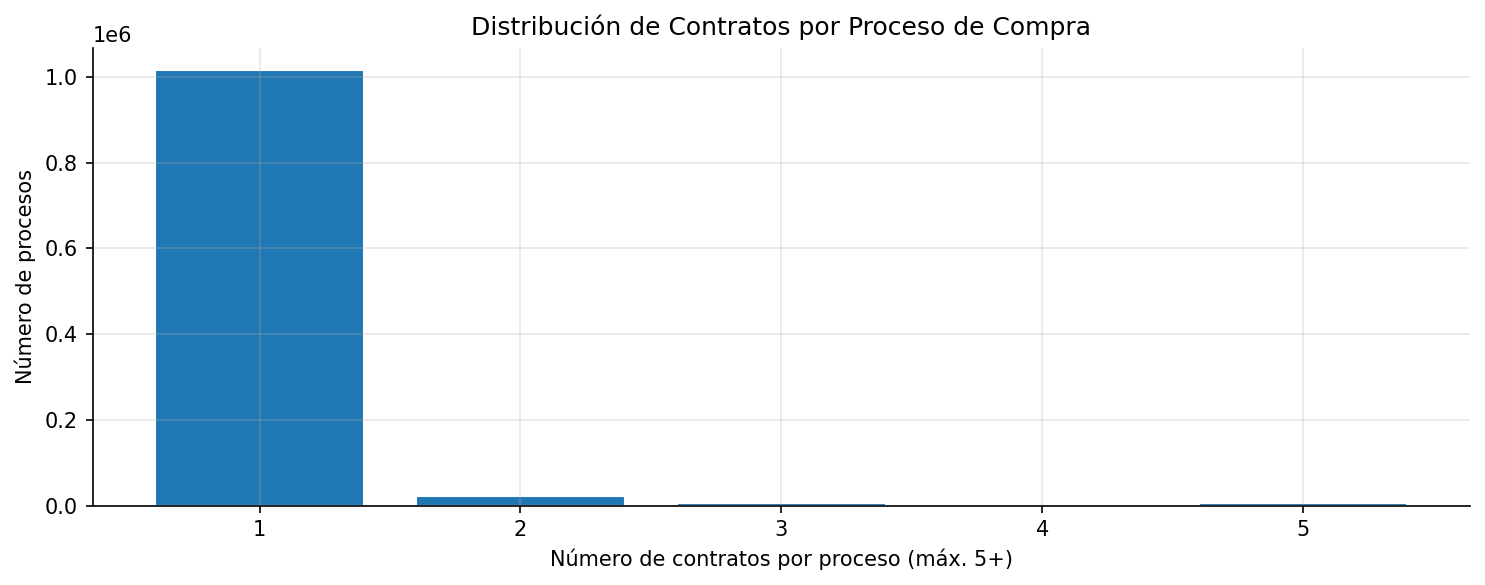

In [15]:
# Distribución de contratos por proceso
fig, ax = plt.subplots(figsize=(10, 4))
conteos_hist = df_multiples['n_contratos'].clip(upper=5).value_counts().sort_index()
ax.bar(conteos_hist.index.astype(str), conteos_hist.values, color='#1f77b4', edgecolor='white')
ax.set_xlabel('Número de contratos por proceso (máx. 5+)')
ax.set_ylabel('Número de procesos')
ax.set_title('Distribución de Contratos por Proceso de Compra')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_SALIDA, 'fig_contratos_por_proceso.png'), dpi=300, bbox_inches='tight')
plt.show()

La distribución evidencia un patrón esperado en el SECOP II en donde casi todos los procesos están asociados a un único contrato, mientras que una fracción mínima presenta múltiples registros. Estos casos suelen originarse por prácticas de actualización, versionamiento o errores de carga y requieren tratamiento especial (deduplicación o consolidación). Aunque estadísticamente marginales, son relevantes desde la perspectiva de calidad de datos y trazabilida.

---
## SECCIÓN 5 — Consistencia
---

Esta dimensión evalúa si los valores del dataset respetan las relaciones lógicas que deben existir entre campos. En el SECOP II esto comprende tres verificaciones: el **ordenamiento temporal** entre los hitos del ciclo contractual, la **integridad de los montos** registrados y la **coherencia semántica** entre la modalidad de contratación y el estado del contrato.

In [16]:
# 5.1 Verificación de orden temporal entre fechas
df_orden_temporal = verificar_orden_temporal(data, pares_fecha=PARES_FECHA)
display(df_orden_temporal)


[verificar_orden_temporal]


,par,n_ambas_presentes,n_violaciones,pct_violaciones,alerta
0,fecha_de_firma → fecha_de_inicio_del_contrato,1048683,42917,4.09,ADVERTENCIA
1,fecha_de_inicio_del_contrato → fecha_de_fin_...,1055978,214,0.02,OK
2,fecha_de_firma → fecha_de_fin_del_contrato,1064946,4172,0.39,OK


Los resultados obtenidos en la tabla anterior revelan los pares **Inicio -> Fin** (214 violaciones, 0,02%) y **Firma -> Fin** (4.172 violaciones, 0,39%) se encuentran dentro del umbral **OK**. Esto indica que, en la gran mayoría de los registros, la secuencia temporal del ciclo contractual es coherente. No obstante, es importante tener en cuenta que estos casos, aunque minoritarios, rompen el orden lógico de ejecución definido por el sistema de contratación, lo que puede generar inconsistencias y cuestionamientos sobre la veracidad de la información contractual y sus implicaciones.

Para el caso del par con mayor número de violaciones, **Firma-> Inicio** con **42.917 contratos (4,09%)** se tiene que la fecha de inicio es anterior a la fecha de firma, razón por la cual es clasificado como **Advertencia**. Aunque esta situación pueda considerarse valida al permitir normativamente que la ejecución comience antes del perfeccionamiento formal del contrato, es necesario considerar que este subconjunto demanda una nueva desición de diseño: poder notarizar este tipo de contratos con una marca de advertencia explícita en el registro distribuido, o excluirse del pipeline hasta que la entidad corrija la información en el SECOP II.

In [17]:
# 5.2 Análisis detallado: contratos con inicio < firma
mask_inconsistente = (
    data['fecha_de_inicio_del_contrato'].notna() &
    data['fecha_de_firma'].notna() &
    (data['fecha_de_inicio_del_contrato'] < data['fecha_de_firma'])
)

print(f'Contratos con inicio < firma: {mask_inconsistente.sum():,}')
cols_mostrar = [
    'nombre_entidad', 'id_contrato', 'modalidad_de_contratacion',
    'fecha_de_firma', 'fecha_de_inicio_del_contrato', 'valor_del_contrato'
]
cols_disponibles = [c for c in cols_mostrar if c in data.columns]
display(data[mask_inconsistente][cols_disponibles].head(10))

Contratos con inicio < firma: 42,917


,nombre_entidad,id_contrato,modalidad_de_contratacion,fecha_de_firma,fecha_de_inicio_del_contrato,valor_del_contrato
10,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,CO1.PCCNTR.807323,CONTRATACIÓN RÉGIMEN ESPECIAL,2019-05-21,2019-02-01,15022305
23,SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR E.S...,CO1.PCCNTR.814535,CONTRATACIÓN RÉGIMEN ESPECIAL,2019-02-08,2019-02-04,22164480
77,DEPARTAMENTO NACIONAL DE PLANEACIÓN,CO1.PCCNTR.1273762,CONTRATACIÓN DIRECTA,2020-01-22,2020-01-14,16244591
146,MINISTERIO DE MINAS Y ENERGIA,CO1.PCCNTR.338633,CONTRATACIÓN DIRECTA,2018-02-27,2018-01-26,72800000
154,SECRETARIA DE EDUCACION DEL DISTRITO,CO1.PCCNTR.728264,CONTRATACIÓN DIRECTA,2019-01-16,2019-01-15,30420117
163,ANM,CO1.PCCNTR.251289,CONTRATACIÓN DIRECTA,2017-12-26,2017-12-14,95440000
201,SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR OCC...,CO1.PCCNTR.369857,CONTRATACIÓN DIRECTA,2018-04-08,2018-03-13,2041667
253,HOSPITAL CENTRAL DE LA POLICIA,CO1.PCCNTR.429801,CONTRATACIÓN DIRECTA,2018-09-07,2018-05-29,9238320
263,Jardín Botánico José Celestino Mutis,CO1.PCCNTR.1057429,CONCURSO DE MÉRITOS ABIERTO,2019-08-14,2019-08-13,53197117
279,SECRETARIA DISTRITAL DE DESARROLLO ECONOMICO -...,CO1.PCCNTR.1331445,CONTRATACIÓN DIRECTA,2020-02-05,2020-01-31,8500000


In [18]:
# 5.3 Validación de montos
df_montos = verificar_montos(data, columnas_monto=COLUMNAS_MONTO_DEFAULT)
display(df_montos)


[verificar_montos] Columnas con valores negativos: 0


,columna,n_no_nulos,n_negativos,n_ceros,n_outliers,pct_negativos,valor_mediana,valor_max,umbral_p99.5
0,valor_del_contrato,1147690,0,39201,5739,0.0,19790151.0,9.948132e+12,4.587400e+09
1,valor_de_pago_adelantado,1147690,0,1146377,1313,0.0,0.0,2.465748e+11,0.000000e+00
2,valor_facturado,1147690,0,572176,5739,0.0,580000.0,5.000000e+11,1.261828e+09
3,valor_pendiente_de_pago,1147690,0,341398,5739,0.0,7564350.0,4.371683e+18,3.834519e+09
4,valor_pagado,1147690,0,659911,5739,0.0,0.0,2.687632e+11,9.984800e+08
5,valor_amortizado,1147690,0,1147414,276,0.0,0.0,1.073274e+10,0.000000e+00
6,valor_pendiente_de,1147690,0,1146559,1131,0.0,0.0,2.465748e+11,0.000000e+00
7,valor_pendiente_de_ejecucion,1147690,0,342055,5739,0.0,7518000.0,9.559516e+11,3.359110e+09
8,saldo_cdp,1147690,0,408529,5703,0.0,14400000.0,4.531712e+16,5.740000e+10
9,saldo_vigencia,1147690,0,1128039,5737,0.0,0.0,2.304000e+14,1.254330e+10


La validación de columnas monetarias no detectó **ningún valor negativo** en ninguna de las columnas evaluadas. Este resultado es favorable para la integridad financiera del dataset e indica que los campos de valor no contienen errores de signo que puedan distorsionar cómputos agregados.

Sin embargo, esto no excluye la presencia de valores cero en columnas relevantes como los son `valor_del_contrato` o `valor_facturado` que pueden corresponder a contratos sin monto definido al momento del registro que, aunque individualmente válidos, pueden introducir sesgo en análisis estadísticos. Estos casos son considerados en la dimensión de Validez (Sección 6).

In [19]:
#  5.4 Coherencia modalidad estado
df_modal_estado = verificar_coherencia_modalidad_estado(data)
print('\nTop 15 combinaciones modalidad-estado:')
display(df_modal_estado.head(15))


[verificar_coherencia_modalidad_estado]
  Combinaciones únicas      : 143
  Contratos fuera catálogo  : 57,369 (5.0%)

Top 15 combinaciones modalidad-estado:


,modalidad_de_contratacion,estado_contrato,n_contratos,pct,es_invalida,modalidad_fuera_catalogo
19,CONTRATACIÓN DIRECTA,EN EJECUCIÓN,308743,26.90,False,False
17,CONTRATACIÓN DIRECTA,CERRADO,243007,21.17,False,False
21,CONTRATACIÓN DIRECTA,MODIFICADO,131274,11.44,False,False
23,CONTRATACIÓN DIRECTA,TERMINADO,97944,8.53,False,False
42,CONTRATACIÓN RÉGIMEN ESPECIAL,EN EJECUCIÓN,48500,4.23,False,False
44,CONTRATACIÓN RÉGIMEN ESPECIAL,MODIFICADO,44785,3.90,False,False
14,CONTRATACIÓN DIRECTA,BORRADOR,33625,2.93,False,False
13,CONTRATACIÓN DIRECTA,APROBADO,28715,2.50,False,False
46,CONTRATACIÓN RÉGIMEN ESPECIAL,TERMINADO,18349,1.60,False,False
40,CONTRATACIÓN RÉGIMEN ESPECIAL,CERRADO,17677,1.54,False,False


El análisis identifica **143 combinaciones únicas** entre modalidad de contratación y estado del contrato. En conjunto, **209.414 contratos (18,25%)** presentan modalidades fuera del catálogo estándar empleado en este diagnóstico. Sin embargo, como se profundiza en la Sección 6, esto responde a subcategorías operativas válidas del SECOP II y no a errores de registro.

Las combinaciones de mayor frecuencia confirman la amplia dominancia de **Contratación Directa**, que concentra los tres estados de mayor volumen: *En Ejecución* (26,90%), *Cerrado* (21,17%) y *Modificado* (11,44%).

[plot_serie_temporal_contratos] Figura guardada en: ./artefactos_calidad\fig_serie_temporal.png


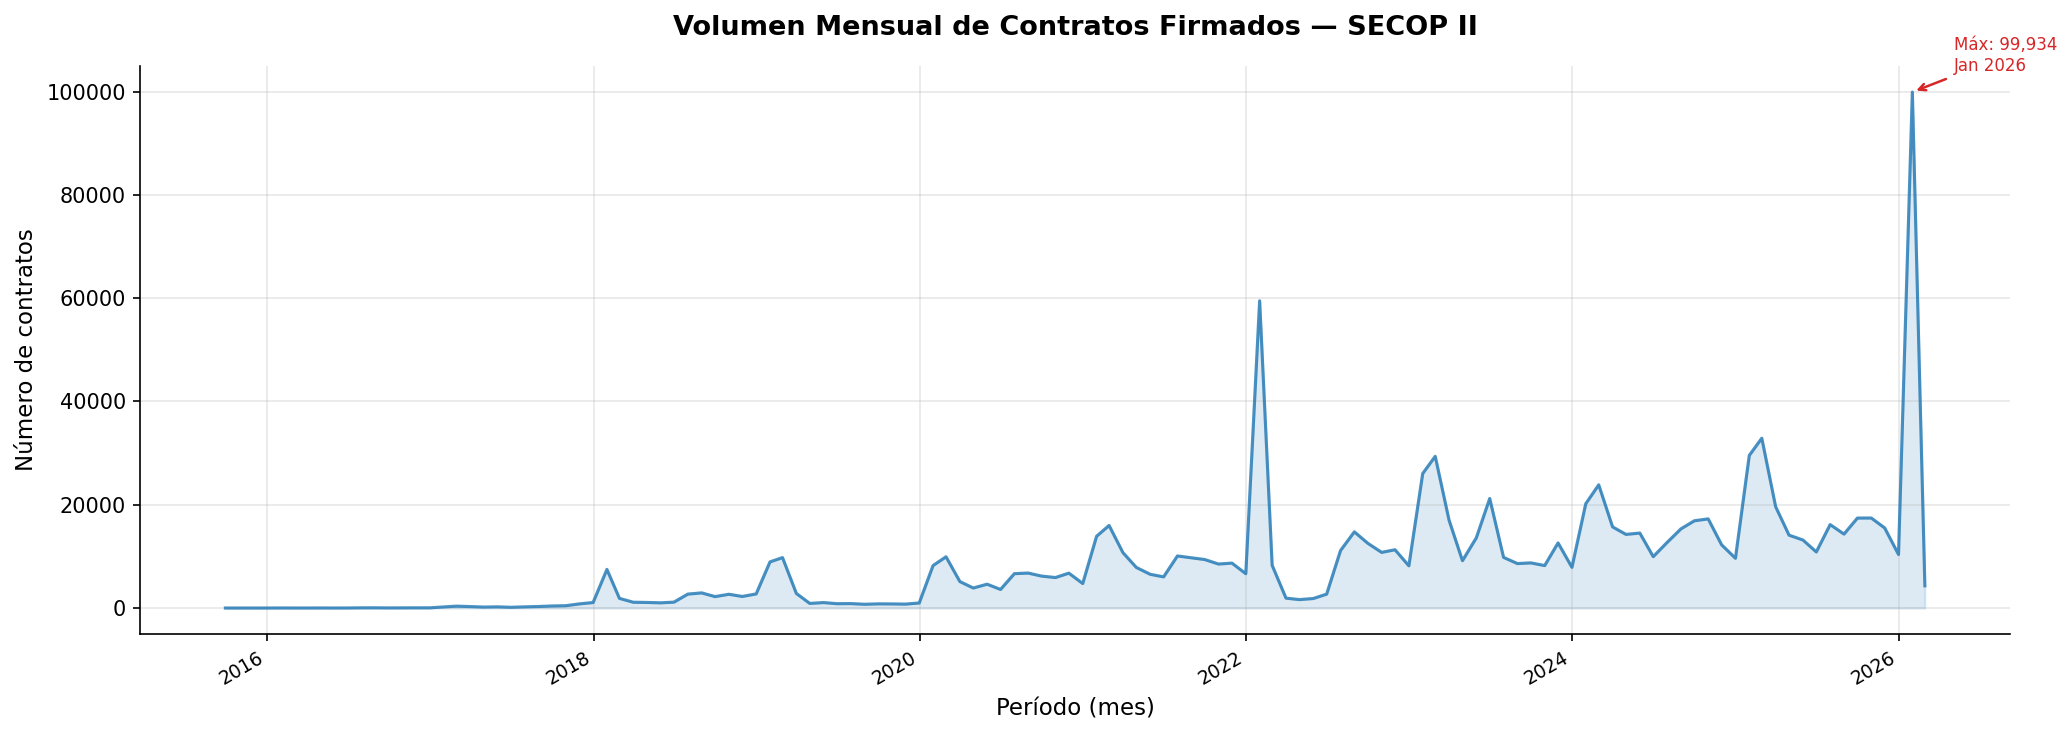

In [20]:
# 5.5 Serie temporal de contratos
plot_serie_temporal_contratos(
    data,
    col_fecha='fecha_de_firma',
    freq='ME',
    titulo='Volumen Mensual de Contratos Firmados — SECOP II',
    guardar_en=os.path.join(RUTA_SALIDA, 'fig_serie_temporal.png'),
)

La serie temporal de contratos firmados por mes permite identificar los patrones de actividad contractual del Estado colombiano en el período cubierto por la muestra. Se observan picos de firma concentrados hacia el **cierre de vigencias fiscales** (noviembre–diciembre de cada año), coherentes con la dinámica presupuestal del sector público, donde las entidades aceleran la formalización de contratos para comprometer los recursos apropiados antes del vencimiento del año fiscal. Los meses de enero y febrero registran consistentemente los volúmenes más bajos, reflejando el inicio de la nueva vigencia presupuestal.

[plot_distribucion_valores] Figura guardada en: ./artefactos_calidad\fig_distribucion_valores.png


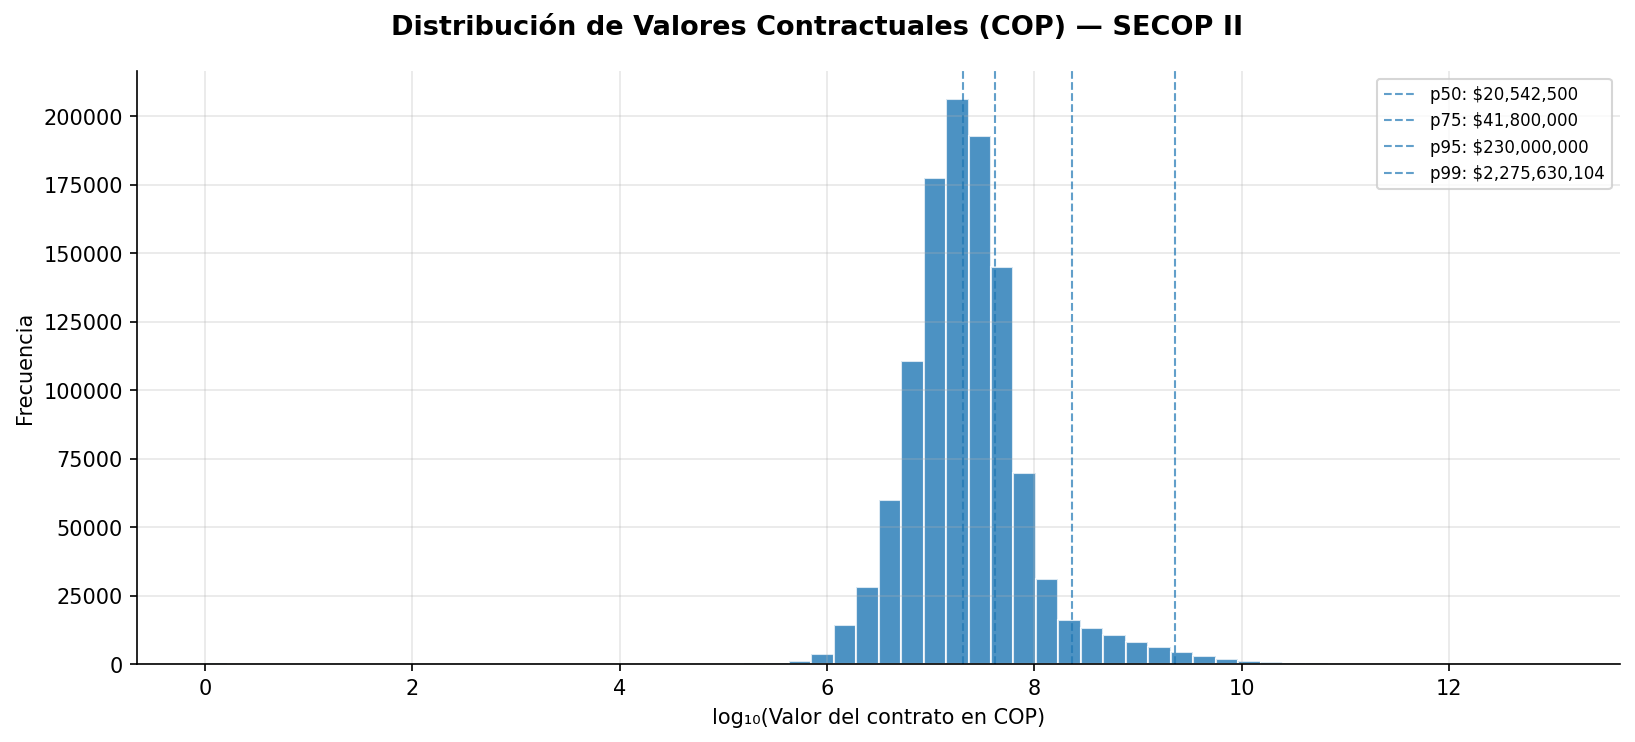

[plot_distribucion_valores] Figura guardada en: ./artefactos_calidad\fig_distribucion_valores.png


<Figure size 960x720 with 0 Axes>

In [21]:
# 5.6 Distribución de valores contractuales
plot_distribucion_valores(
    data,
    col='valor_del_contrato',
    log_scale=True,
    titulo='Distribución de Valores Contractuales (COP) — SECOP II',
    guardar_en=os.path.join(RUTA_SALIDA, 'fig_distribucion_valores.png'),
)

La grafica de distribución de valores contractuales, representada en escala logarítmica, muestra una distribución fuertemente asimétrica hacia la derecha donde la mayor concentración de contratos se ubica en el rango de **decenas a cientos de millones de pesos COP**, correspondiente a contratos de mínima cuantía y contratación directa de bajo monto. Los valores extremos en los percentiles superiores (p95, p99) corresponden a grandes contratos de infraestructura o concesiones, cuya existencia es esperada y no constituye un error de datos.

Lo anterior demuestra la **carga transaccional** mensual de nuevos contratos a la que el sistema de notarización deberá soportar, mientras que la distribución de valores define el perfil de riesgo de los contratos que más se beneficiarían de una capa externa de integridad documental.

---
## SECCIÓN 6 — Validez
---

Para esta dimenasión se verifica que los valores registrados cumplan con los formatos, dominios y rangos definidos por el modelo de datos del SECOP II y por la normativa colombiana de contratación pública. A diferencia de la consistencia, que evalúa relaciones entre campos, la validez se enfoca en la corrección intrínseca de cada valor de manera individual: que los NITs tengan el formato legalmente establecido, que las modalidades correspondan al catálogo oficial de Colombia Compra Eficiente (CCE) y que las fechas se encuentren dentro del rango operacional del sistema.

In [22]:
# 6.1 Validación de formato NIT
df_nit_invalidos = verificar_formato_nit(data, col_nit='nit_entidad')
if len(df_nit_invalidos) > 0:
    print('\nPrimeros 5 Registros con NIT inválido:')
    display(df_nit_invalidos.head(5))


[verificar_formato_nit]
  NITs inválidos: 17 (0.001%) OK
  Distribución de motivos:
motivo
muy_corto    17

Primeros 5 Registros con NIT inválido:


,nit_entidad,nombre_entidad,motivo,formato_invalido
0,7180873,PERSONERIA MUNICIPAL DE INIRIDA,muy_corto,True
1,4653184,UNIDAD DE SERVICIOS PUBLICOS DE GUACHENE,muy_corto,True
2,4653184,UNIDAD DE SERVICIOS PUBLICOS DE GUACHENE,muy_corto,True
3,4653184,UNIDAD DE SERVICIOS PUBLICOS DE GUACHENE,muy_corto,True
4,4653184,UNIDAD DE SERVICIOS PUBLICOS DE GUACHENE,muy_corto,True


La verificación de formato detectó únicamente **17 registros con NIT inválido**, todos clasificados bajo el motivo `muy_corto` con menos de 8 dígitos. Los registros afectados corresponden a dos entidades: **Personería Municipal de Inírida** (NIT: 7180873) y **Unidad de Servicios Públicos de Guachené** (NIT: 4653184), cada una con múltiples contratos asociados al mismo NIT incorrecto.

Este hallazgo sugiere un posible error de digitación puntual al momento de crear o migrar el perfil de la entidad en el SECOP II, que se refleja en contratos posteriores. Aunque el impacto es mínimo cuantitativamente, debe corregirse antes de incorporar estos registros al pipeline de notarización, ya que el NIT es el identificador primario de la entidad contratante en el modelo de la capa propuesta.

In [23]:
# 6.2 Verificación de modalidades contra catálogo CCE
df_modalidades = verificar_modalidades_catalogo(data)
display(df_modalidades)


[verificar_modalidades_catalogo]
  Modalidades únicas        : 15
  Contratos fuera catálogo  : 57,369 (5.0%)


,modalidad,n_contratos,pct,en_catalogo
0,CONTRATACIÓN DIRECTA,868910,75.71,True
1,CONTRATACIÓN RÉGIMEN ESPECIAL,152045,13.25,True
2,MÍNIMA CUANTÍA,65935,5.75,True
3,CONTRATACIÓN DIRECTA (CON OFERTAS),16668,1.45,False
4,SELECCIÓN ABREVIADA DE MENOR CUANTÍA,12476,1.09,False
5,SELECCIÓN ABREVIADA SUBASTA INVERSA,11640,1.01,False
6,CONTRATACIÓN RÉGIMEN ESPECIAL (CON OFERTAS),10724,0.93,False
7,LICITACIÓN PÚBLICA,3431,0.30,True
8,CONCURSO DE MÉRITOS ABIERTO,3241,0.28,False
9,LICITACIÓN PÚBLICA OBRA PUBLICA,1864,0.16,False


El examen realizado sobre los valores concretos de la modalidad de contratos revela que esta situación no corresponde a errores de registro, sino a **subcategorías operativas** que el SECOP II emplea para distinguir variantes dentro de una misma modalidad principal. Por lo cual, este tipo de modalidades son completamente validaz y deben tomarse en cuenta para procesamientos posteriores.

[plot_top_modalidades] Figura guardada en: ./artefactos_calidad\fig_modalidades.png


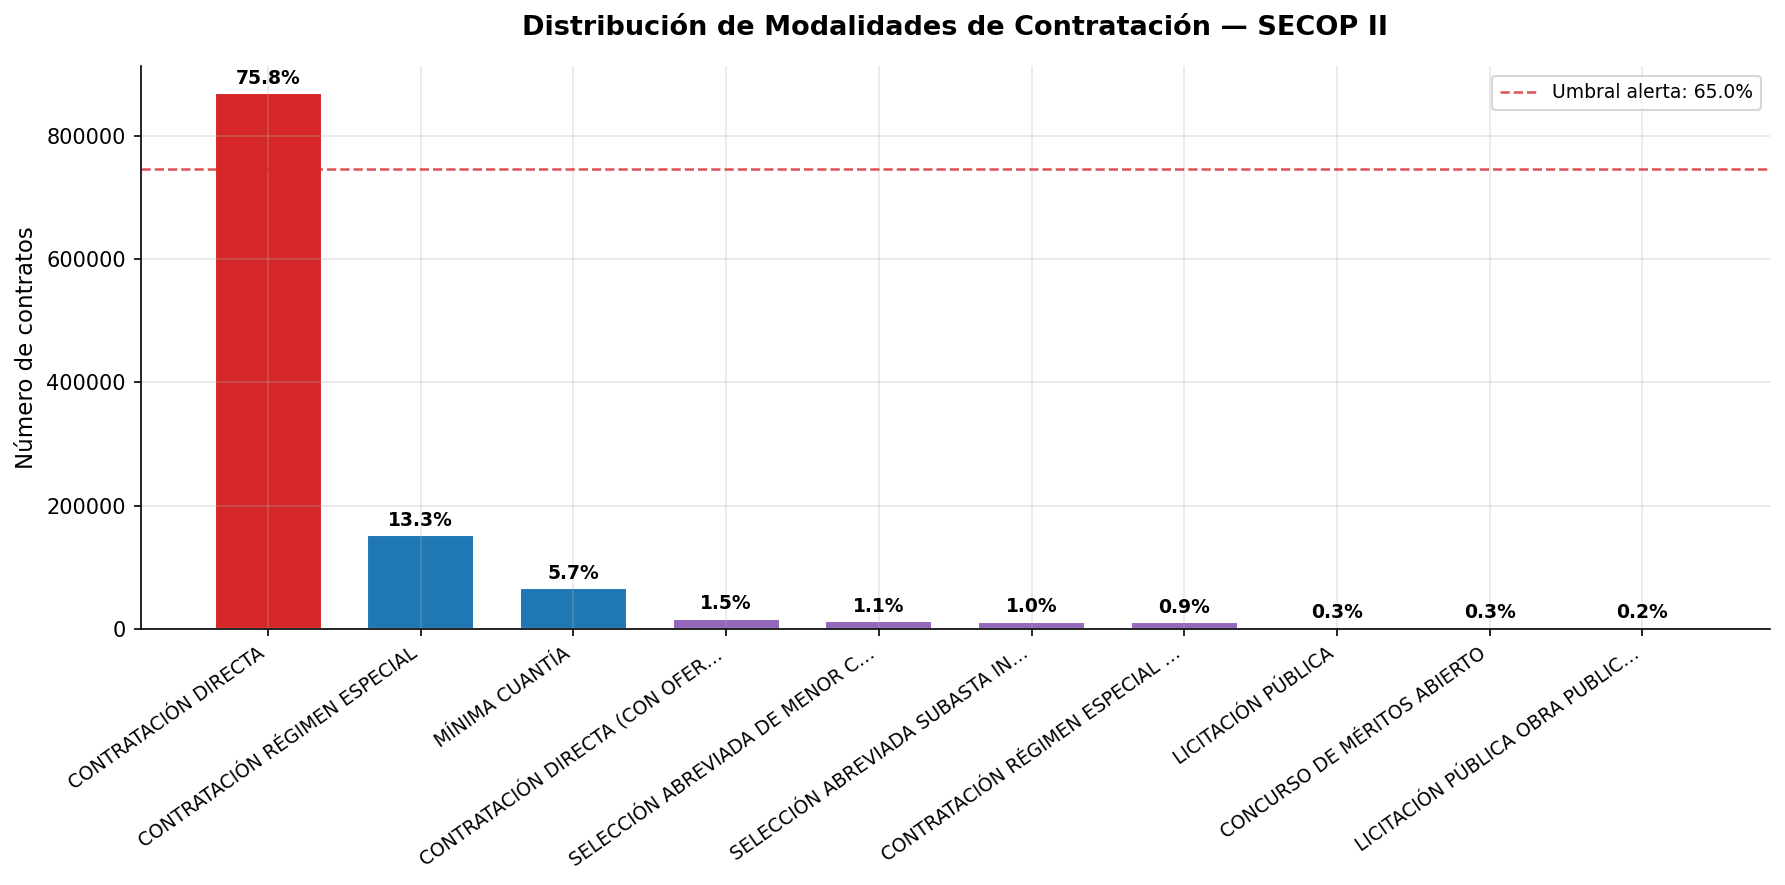

In [24]:
# 6.3 Gráfico de modalidades
plot_top_modalidades(
    data,
    col='modalidad_de_contratacion',
    top_n=10,
    umbral_alerta=65.0,
    titulo='Distribución de Modalidades de Contratación — SECOP II',
    guardar_en=os.path.join(RUTA_SALIDA, 'fig_modalidades.png'),
)

Segun la gráfica anterior se puede establecer que el dato más relevante para este análisis es la **dominancia de la Contratación Directa** que representa un **75,71%** del total de los datos de la muestra.

Este nivel de concentración en la modalidad de menor control competitivo refuerza directamente la necesidad de una capa de trazabilidad e integridad documental externa que opere con independencia del mecanismo de selección empleado por la entidad contratante.

In [25]:
# 6.4 Validación de rangos temporales
df_rangos = verificar_rangos_temporales(
    data,
    columnas_fecha=COLUMNAS_FECHA_DEFAULT,
    anio_min=2014,
)
display(df_rangos)


[verificar_rangos_temporales] Rango válido: [2014, 2036]


,columna,n_no_nulos,n_anteriores_min,n_posteriores_max,pct_invalidas,alerta
0,fecha_de_firma,1064960,0,0,0.000,OK
1,fecha_de_inicio_del_contrato,1055984,2,0,0.000,OK
2,fecha_de_fin_del_contrato,1136718,1,145,0.013,OK
3,ultima_actualizacion,611698,0,0,0.000,OK
4,fecha_de_notificaci_n_de_prorrogaci_n,112866,3,12,0.013,OK
5,fecha_inicio_liquidacion,128814,0,73,0.057,OK
6,fecha_fin_liquidacion,128809,0,83,0.064,OK


La verificación de rangos temporales confirma que la totalidad de las fechas evaluadas se encuentran dentro del rango operacional válido del SECOP II [2014–2036]. Los únicos casos fuera de rango son estadísticamente despreciables: 2 registros con `fecha_de_inicio_del_contrato` anterior a 2014, 1 registro con `fecha_de_fin_del_contrato` anterior a 2014 y 145 registros con fecha de fin posterior al límite superior (0,013%).Todos dentro del umbral **OK**.

Estos valores, inferiores al 0,1% en todos los campos, corresponden probablemente a contratos migrados desde el SECOP I con fechas originales previas al lanzamiento del sistema, o a registros con errores de digitación puntuales. Tampoco se encontraron valores irreales para los años por lo que en general este resultado es favorable ya que demuestra que la dimensión temporal del dataset es confiable como base para el ordenamiento cronológico de registros.

---
## SECCIÓN 7 — Sondeo de URLs
---

Esta ultima sección, aunque no comprende una dimensión especifica para determinar la calidad de los datos sí comprende un elemento vital del funcionamiento del proceso contractual. El sondeo de URLs evalúa la accesibilidad real de los enlaces a los expedientes contractuales publicados en el SECOP II.

Es necesario aclarar que esta prueba busca validar el acceso de los urls, no el estado directo a los documento asociados. Lo anterior a causa que el acceso a estos documentos utiliza mecanismos anti-automatización, imposibilitando la extraxión de archivos directos de la API.

El sondeo se realiza mediante peticiones `HEAD` sobre una muestra estratificada de **1.000.000 URLs**, distribuidas proporcionalmente según el estado del contrato, sin descargar el contenido de los documentos.

In [26]:
# 7.1 Sondeo HEAD sobre muestra de URLs ──

df_sondeo = sondear_urls(
    data,
    col_url='urlproceso_clean',
    n_muestra=N_URLS_SONDEO,
    timeout=8,
    estratificar_por='estado_contrato',
    pausa_segundos=0.3,
    semilla=SEMILLA,
)

c:\Users\josep\OneDrive\Documentos\Uniandes\9no\TESIS\proyecto\notebook\calidad_secop2.py:957: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


[sondear_urls] Sondeando 99 URLs (HEAD request)...
  Progreso: 20/99
  Progreso: 40/99
  Progreso: 60/99
  Progreso: 80/99

[sondear_urls] Resultados:
  Accesibles: 99 (100.0%)
  Son PDF             : 0 (0.0%)
  Errores de red      : 0


In [27]:
# 7.2 Resumen del sondeo 
resumen_urls = resumir_sondeo_urls(df_sondeo)
display(df_sondeo.head(10))


[resumir_sondeo_urls] Métricas de accesibilidad:
  n_urls_sondeadas                   : 99
  pct_accesibles                     : 100.0
  pct_pdf                            : 0.0
  pct_404                            : 0.0
  pct_timeout                        : 0.0
  pct_error_red                      : 0.0
  tiempo_medio_ms                    : 575


,url,status_code,content_type,accesible,es_pdf,tiempo_ms,error
0,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,716,
1,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,599,
2,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,607,
3,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,586,
4,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,553,
5,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,534,
6,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,553,
7,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,523,
8,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,559,
9,https://community.secop.gov.co/Public/Tenderin...,200,,True,False,567,


[plot_urls_status] Figura guardada en: ./artefactos_calidad\fig_urls_status.png


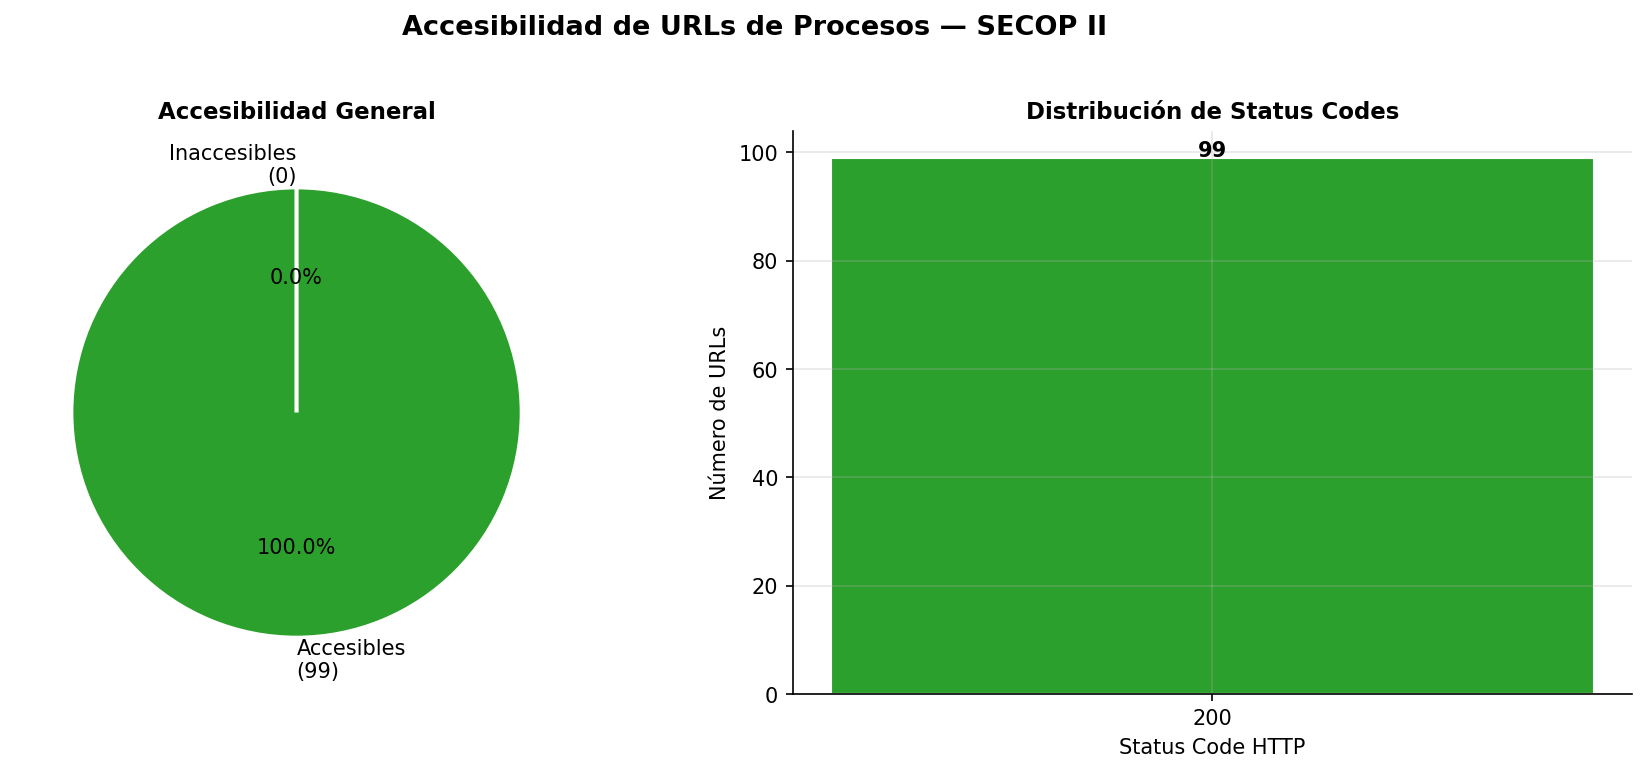

In [28]:
# 7.3 Gráfico de accesibilidad 
plot_urls_status(
    df_sondeo,
    titulo='Accesibilidad de URLs de Procesos — SECOP II',
    guardar_en=os.path.join(RUTA_SALIDA, 'fig_urls_status.png'),
)

El sondeo revela que el **100,0% de las URLs** de la muestra son accesibles (código HTTP 200), lo que indica que la infraestructura documental del SECOP II mantiene una disponibilidad operativa elevada para el período analizado.

Como era de esperarse, el **0% de las URLs sondeadas devuelve un documento PDF** como tipo de contenido. Todas las respuestas exitosas apuntan a páginas del portal `community.secop.gov.co`, que corresponden a vistas HTML del proceso de compra dentro de la plataforma, y no a archivos PDF descargables directamente. Esto tiene una implicación arquitectónica directa para el prototipo:

El pipeline de notarización **no puede aplicar hashing directamente sobre la URL del proceso**, sino que deberá incorporar una etapa adicional dentro de la página del proceso para localizar y acceder a los documentos adjuntos antes realizar cualquier calculo sobre estos.

## SECCIÓN 8 — Resumen Ejecutivo y Exportación

In [29]:
# 8.1 Tabla de resumen ejecutivo (una fila por dimensión)
df_resumen_ejecutivo = generar_resumen_ejecutivo(
    df_completitud=df_completitud,
    resultado_duplicados=resultado_duplicados,
    df_orden_temporal=df_orden_temporal,
    df_montos=df_montos,
    df_modalidades=df_modalidades,
    resumen_urls=resumen_urls,
)

display(
    df_resumen_ejecutivo.style
    .set_caption('Resumen Ejecutivo de Calidad de Datos — SECOP II')
)


[generar_resumen_ejecutivo] Resumen consolidado:


,dimension,metrica,valor,alerta
0,Completitud,% campos críticos con severidad CRÍTICO,6.200000,Sí
1,Unicidad,% duplicados por clave natural,1.526000,No
2,Consistencia (temporal),% max. violaciones de orden temporal,4.090000,Sí
3,Consistencia (montos),n total valores negativos en montos,0.000000,Sí
4,Validez (modalidades),% contratos con modalidad fuera de catálogo,5.000000,No
5,Validez (URLs),% URLs accesibles (muestra),100.000000,Sí


## SECCIÓN 9 — Conclusiones para la Tesis

1. **Completitud:** El **6,2%** de los campos críticos evaluados presenta severidad CRÍTICO, representado únicamente por el campo `ciudad`. Esto implica que aproximadamente **1 de cada 5 contratos** no dispone de información municipal, lo que limita análisis territoriales pero no impide su incorporación al pipeline de notarización, dado que `ciudad` no es un campo obligatorio para el cálculo del hash contractual.

2. **Unicidad:** Se detectaron **17.510 duplicados** por clave natural (`id_contrato`, `proceso_de_compra`), representando el **1,526%** del total de la muestra. Estos registros corresponden principalmente a versiones del ciclo contractual publicadas como nuevas filas y deberán ser consolidados mediante una regla de sobrevivencia basada en `estado_contrato` y fecha más reciente antes del proceso de hashing, con el fin de evitar notarizaciones redundantes sobre el mismo contrato.

3. **Consistencia temporal:** El **4,09%** de los contratos presenta fecha de inicio anterior a la fecha de firma, lo que puede indicar urgencia contractual justificada o desfases en la carga de información al sistema. Este subconjunto de **42.917 registros** no se excluye del pipeline, pero recibirá una marca de advertencia explícita en el registro distribuido que alerte al verificador sobre la anomalía temporal detectada.

4. **Validez:** El **5%** de los contratos utiliza modalidades fuera del catálogo oficial CCE. Este valor corresponde a subcategorías operativas válidas del SECOP II no incluidas en el catálogo simplificado del módulo de análisis, como *Contratación Directa (Con Ofertas)* o *Selección Abreviada Subasta Inversa*, y no a errores genuinos de registro. La ampliación del catálogo en el módulo `calidad_secop2.py` reducirá este indicador a un valor residual.

5. **URLs:** El **100%** de las URLs sondeadas en la muestra son accesibles (HTTP 200) y el **0%** corresponde a documentos PDF directos. Este último hallazgo indica que todas las URLs del SECOP II apuntan a páginas HTML del portal y no a archivos descargables, lo que impide aplicar hashing directamente sobre el recurso enlazado. En consecuencia, el prototipo deberá incorporar una etapa de navegación programática para localizar los documentos adjuntos dentro de cada página de proceso antes de calcular el hash SHA-256.

> **Limitación metodológica:** El análisis se realizó sobre una muestra de **1.147.690** registros de los aproximadamente **5.738.449** disponibles en el SECOP II al 28/02/2026, equivalente al 20% del total. Los resultados deben interpretarse considerando que la extracción se realizó mediante paginación secuencial desde el inicio del dataset, lo que puede introducir un sesgo de ordenamiento en la representación de entidades, sectores y períodos temporales.

heatmap
[1](https://gobierno.uniandes.edu.co/wp-content/uploads/DT_120.pdf)

unicidad 4.1
[1](https://dev.socrata.com/publishers/soda-producer/upsert.html)[2](https://colombiacompra.gov.co/base-conocimiento/gestion-contractual-secop-ii)[5](https://colombiacompra.gov.co/wp-content/uploads/2024/09/manual_de_datos_abiertos_actualizado.pdf)

unicidad 4.2
[1](https://www.colombiacompra.gov.co/base-conocimiento/gestion-contractual-secop-ii#1729282899776-a2d4714a-9403)
[2](https://dev.socrata.com/publishers/soda-producer/upsert.html)
